# Tarea 1 — limpieza y unificación

Tomo los 3 CSVs, los limpio por separado y armo un dataset unificado para modelar alquileres. El detalle de qué problemas hay en cada plataforma está en `00_eda.ipynb`. Acá ejecuto las decisiones.

In [1]:
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA = Path('../data')
OUT = Path('../output')
OUT.mkdir(exist_ok=True)

# tipo de cambio constante para el periodo. mediana USD=735, mediana ARS=810k -> implicito ~1100
USD_ARS = 1100

# rango admisible del precio mensual en ARS (filtra typos sin descartar cola legitima)
PRECIO_MIN = 100_000
PRECIO_MAX = 10_000_000

## schema target

Antes de meter mano a cada plataforma defino a qué quiero llegar. Las tres plataformas tienen que terminar en un único dataframe con estas columnas:

```
listing_id          str       prefijo de plataforma + id original
plataforma          cat       A / B / C
fecha_publicacion   date
tipo_propiedad      cat       depto / ph / casa
barrio              cat       12-13 únicos normalizados
lat, lng            float
precio_ars_mes      float     target, USD convertido a ARS
moneda_origen       cat       ARS / USD (flag)
m2_total            float
m2_cubierto         float
ambientes           Int64     nullable
dormitorios         Int64
banos               Int64
antiguedad_anios    float     0 = "a estrenar"
cochera             boolean
balcon              boolean
pileta              boolean
expensas            float     clipped a p99
flag_missing_*      bool      por feature crítica con missing informativo
```

Tipos categóricos donde corresponde para no inflar la memoria con strings repetidos. Int64 nullable porque ambientes/dorm/baños pueden faltar (sobre todo en C que sale por regex). Booleanos nullable por la misma razón.

## A

In [2]:
# cargo A en latin1 (utf-8 rompe los ñ y arrastra barrios fantasma)
a = pd.read_csv(DATA / 'listings_plataforma_A.csv', encoding='latin1')
a.shape

(3662, 18)

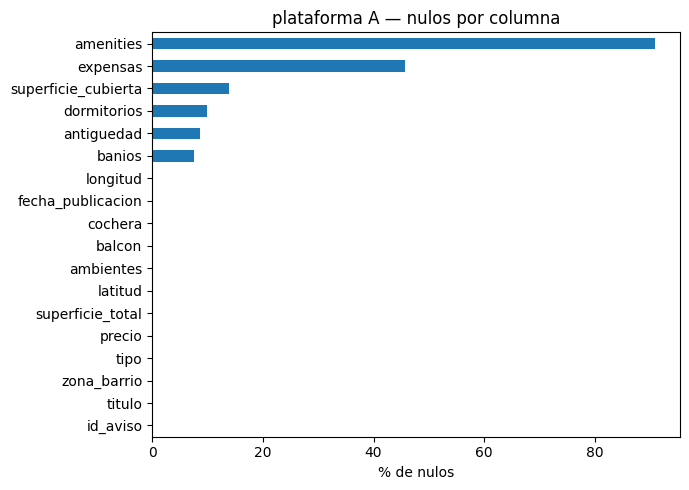

In [3]:
# nulos % por columna en A: amenities y expensas saltan a la vista
nulos_a = (a.isna().mean() * 100).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(7, 5))
nulos_a.plot(kind='barh', ax=ax)
ax.set_xlabel('% de nulos')
ax.set_title('plataforma A — nulos por columna')
plt.tight_layout()
plt.show()

In [4]:
# parseo precio: detecto moneda, extraigo numero, convierto USD a ARS
p = a['precio'].astype(str)
moneda = np.where(p.str.contains(r'USD|U\$S|us\$', case=False, regex=True), 'USD', 'ARS')
num = pd.to_numeric(p.str.extract(r'([\d.]+)')[0].str.replace('.', '', regex=False), errors='coerce')
a['precio_ars_mes'] = np.where(moneda == 'USD', num * USD_ARS, num)
a['moneda_origen'] = moneda
a['precio_ars_mes'] = a['precio_ars_mes'].where(a['precio_ars_mes'].between(PRECIO_MIN, PRECIO_MAX))
a[['precio', 'moneda_origen', 'precio_ars_mes']].head()

,precio,moneda_origen,precio_ars_mes
0,1.267.000,ARS,1267000.0
1,584.000,ARS,584000.0
2,252.000,ARS,252000.0
3,546.000,ARS,546000.0
4,337.000,ARS,337000.0


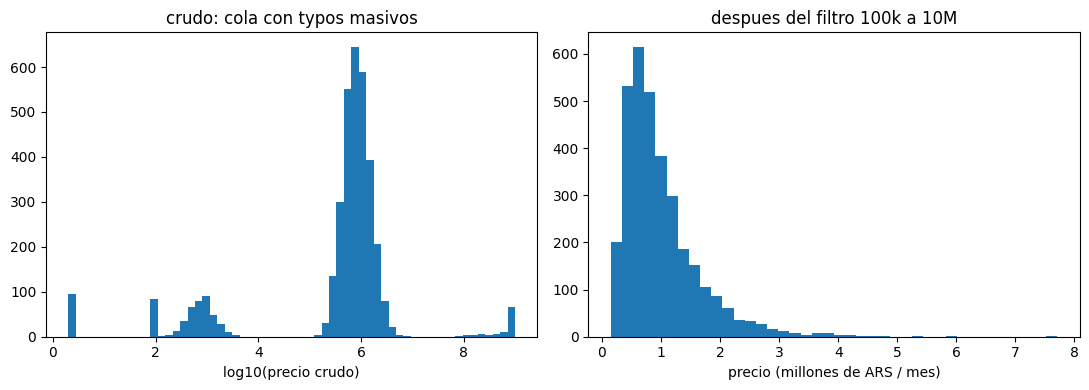

In [5]:
# precio en A crudo vs despues del filtro 100k-10M. Los typos masivos se ven en escala log
crudo = pd.to_numeric(p.str.extract(r'([\d.]+)')[0].str.replace('.', '', regex=False), errors='coerce')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(np.log10(crudo.dropna() + 1), bins=60)
axes[0].set_xlabel('log10(precio crudo)')
axes[0].set_title('crudo: cola con typos masivos')

axes[1].hist(a['precio_ars_mes'].dropna() / 1e6, bins=40)
axes[1].set_xlabel('precio (millones de ARS / mes)')
axes[1].set_title('despues del filtro 100k a 10M')

plt.tight_layout()
plt.show()

In [6]:
# lat/lng vienen como string, ~8% usa coma decimal
a['lat'] = pd.to_numeric(a['latitud'].astype(str).str.replace(',', '.', regex=False), errors='coerce')
a['lng'] = pd.to_numeric(a['longitud'].astype(str).str.replace(',', '.', regex=False), errors='coerce')
a[['lat', 'lng']].describe().round(4)

,lat,lng
count,3662.0000,3662.0000
mean,-34.5944,-58.4362
std,0.0290,0.0335
min,-34.6665,-58.5190
25%,-34.6186,-58.4603
50%,-34.5952,-58.4391
75%,-34.5722,-58.4152
max,-34.5064,-58.3320


In [7]:
# saco el primer numero de superficie/ambientes (vienen con sufijos tipo "35 m²" o "4 amb.")
def primer_num(s):
    return pd.to_numeric(s.astype(str).str.extract(r'(\d+)')[0], errors='coerce')

a['m2_total'] = primer_num(a['superficie_total'])
a['m2_cubierto'] = primer_num(a['superficie_cubierta'])
a['ambientes'] = primer_num(a['ambientes'])

In [8]:
# antiguedad: "A estrenar" vale 0, el resto es "X" o "X años"
ant = a['antiguedad'].astype(str).str.lower().str.strip()
a['antiguedad_anios'] = np.where(
    ant.str.contains('estrenar'),
    0.0,
    pd.to_numeric(ant.str.extract(r'(\d+)')[0], errors='coerce'),
)
a['antiguedad_anios'].describe()

count    3342.000000
mean       13.932675
std        13.709386
min         0.000000
25%         4.000000
50%        10.000000
75%        20.000000
max        76.000000
Name: antiguedad_anios, dtype: float64

In [9]:
# cochera/balcon vienen como "Sí"/"No"
for col, src in [('cochera', 'cochera'), ('balcon', 'balcon')]:
    a[col] = a[src].astype(str).str.lower().str.startswith('s')

# pileta no esta como bool en A, miro amenities (90% null) por las dudas
a['pileta'] = a['amenities'].fillna('').astype(str).str.contains(r'pileta|piscina', case=False, regex=True)

In [10]:
# expensas: 46% null y cola muy gorda (max 45M, p99 12M). Clip a p99, no descarto
exp = pd.to_numeric(a['expensas'], errors='coerce')
p99 = exp.quantile(0.99)
a['expensas'] = exp.clip(upper=p99)
p99

np.float64(12177921.99999996)

In [11]:
# normalizo barrio (strip+lower) y tipo (lower)
a['barrio'] = a['zona_barrio'].astype(str).str.strip().str.lower()
a['tipo_propiedad'] = a['tipo'].astype(str).str.lower().replace({'departamento': 'depto'})
a['fecha_publicacion'] = pd.to_datetime(a['fecha_publicacion'], format='%d/%m/%Y', errors='coerce')

In [12]:
# armo el dataframe limpio de A con el schema unificado
a_clean = pd.DataFrame({
    'listing_id': 'A-' + a['id_aviso'].astype(str),
    'plataforma': 'A',
    'fecha_publicacion': a['fecha_publicacion'],
    'tipo_propiedad': a['tipo_propiedad'],
    'barrio': a['barrio'],
    'lat': a['lat'],
    'lng': a['lng'],
    'precio_ars_mes': a['precio_ars_mes'],
    'moneda_origen': a['moneda_origen'],
    'm2_total': a['m2_total'],
    'm2_cubierto': a['m2_cubierto'],
    'ambientes': a['ambientes'],
    'dormitorios': pd.to_numeric(a['dormitorios'], errors='coerce'),
    'banos': pd.to_numeric(a['banios'], errors='coerce'),
    'antiguedad_anios': a['antiguedad_anios'],
    'cochera': a['cochera'],
    'balcon': a['balcon'],
    'pileta': a['pileta'],
    'expensas': a['expensas'],
})
a_clean.shape

(3662, 19)

## B

In [13]:
# cargo B (utf-8) y dropeo constantes
b = pd.read_csv(DATA / 'listings_plataforma_B.csv', encoding='utf-8')
b = b.drop(columns=['category_l1', 'category_l2'])
b.shape

(3639, 16)

In [14]:
# precio ya esta limpio en B, igual aplico el rango admisible para descartar atipicos
precio_b = b['price_ars'].where(b['price_ars'].between(PRECIO_MIN, PRECIO_MAX))

b_clean = pd.DataFrame({
    'listing_id': 'B-' + b['listing_id'].astype(str),
    'plataforma': 'B',
    'fecha_publicacion': pd.to_datetime(b['created_at'], errors='coerce'),
    'tipo_propiedad': b['property_type'].str.lower().replace({'departamento': 'depto'}),
    'barrio': b['neighborhood'].astype(str).str.strip().str.lower(),
    'lat': b['lat'],
    'lng': b['lng'],
    'precio_ars_mes': precio_b,
    'moneda_origen': 'ARS',
    'm2_total': b['total_area_m2'],
    'm2_cubierto': b['covered_area_m2'],
    'ambientes': b['rooms'],
    'dormitorios': b['bedrooms'],
    'banos': b['bathrooms'],
    'antiguedad_anios': b['age_years'],
    'cochera': b['has_garage'],
    'balcon': b['has_balcony'],
    'pileta': b['has_pool'],
    'expensas': np.nan,
})
b_clean.shape

(3639, 19)

## C

In [15]:
# cargo C
c = pd.read_csv(DATA / 'listings_plataforma_C.csv', encoding='utf-8')
c.shape

(3699, 9)

In [16]:
# precio: "$XXX.XXX/mes" o "Consultar". los Consultar quedan NaN (no tengo target)
pp = c['precio_publicado'].astype(str)
c_precio = pd.to_numeric(pp.str.extract(r'(\d[\d.]*)')[0].str.replace('.', '', regex=False), errors='coerce')
c_precio = c_precio.where(c_precio.between(PRECIO_MIN, PRECIO_MAX))
c_precio.describe().round(0)

count       3405.0
mean      990721.0
std       646470.0
min       159000.0
25%       554000.0
50%       817000.0
75%      1222000.0
max      5946000.0
Name: 0, dtype: float64

In [17]:
# saco features de la descripcion via regex (la mitad+ de los listings la trae)
desc = c['descripcion'].fillna('').astype(str).str.lower()

def extraer_int(patron):
    return pd.to_numeric(desc.str.extract(patron)[0], errors='coerce')

c['ambientes']        = extraer_int(r'(\d+)\s*amb')
c['dormitorios']      = extraer_int(r'(\d+)\s*dorm')
c['banos']            = extraer_int(r'(\d+)\s*ba[ñn]')
c['antiguedad_anios'] = extraer_int(r'(\d+)\s*a[ñn]')
c['cochera'] = desc.str.contains('cochera', regex=False)
c['pileta']  = desc.str.contains(r'pileta|piscina', regex=True)
c['balcon']  = desc.str.contains(r'balc[oó]n', regex=True)

In [18]:
# coordenadas vienen pegadas "lat,lng". 40% son nulas
split = c['coordenadas'].astype(str).str.split(',', n=1, expand=True)
c['lat'] = pd.to_numeric(split[0], errors='coerce')
c['lng'] = pd.to_numeric(split[1], errors='coerce') if split.shape[1] > 1 else np.nan

In [19]:
# armo C con el schema unificado
c_clean = pd.DataFrame({
    'listing_id': 'C-' + c['codigo'].astype(str),
    'plataforma': 'C',
    'fecha_publicacion': pd.to_datetime(c['publicado'], format='%d-%m-%Y', errors='coerce'),
    'tipo_propiedad': c['tipo_inmueble'].astype(str).str.lower().replace({'departamento': 'depto'}),
    'barrio': c['barrio'].astype(str).str.strip().str.lower(),
    'lat': c['lat'],
    'lng': c['lng'],
    'precio_ars_mes': c_precio,
    'moneda_origen': 'ARS',
    'm2_total': pd.to_numeric(c['superficie'], errors='coerce'),
    'm2_cubierto': np.nan,
    'ambientes': c['ambientes'],
    'dormitorios': c['dormitorios'],
    'banos': c['banos'],
    'antiguedad_anios': c['antiguedad_anios'],
    'cochera': c['cochera'],
    'balcon': c['balcon'],
    'pileta': c['pileta'],
    'expensas': np.nan,
})
c_clean.shape

(3699, 19)

## unificación

In [20]:
# concateno los 3 limpios
df = pd.concat([a_clean, b_clean, c_clean], ignore_index=True)
df.shape

(11000, 19)

In [21]:
# sin target no entreno: tiro filas sin precio
antes = len(df)
df = df.dropna(subset=['precio_ars_mes']).reset_index(drop=True)
print(f'descarte {antes - len(df)} filas sin precio ({(antes - len(df)) / antes:.1%})')
df.shape

descarte 862 filas sin precio (7.8%)


(10138, 19)

In [22]:
# flags de missing informativo para las features con nulls sistemicos
df['flag_missing_expensas']    = df['expensas'].isna()
df['flag_missing_antiguedad']  = df['antiguedad_anios'].isna()
df['flag_missing_m2_total']    = df['m2_total'].isna()
df[['flag_missing_expensas', 'flag_missing_antiguedad', 'flag_missing_m2_total']].mean().round(3)

flag_missing_expensas      0.823
flag_missing_antiguedad    0.317
flag_missing_m2_total      0.117
dtype: float64

In [23]:
# fijo dtypes finales
for col in ['ambientes', 'dormitorios', 'banos']:
    df[col] = df[col].astype('Int64')

for col in ['cochera', 'balcon', 'pileta']:
    df[col] = df[col].astype('boolean')

df['plataforma'] = df['plataforma'].astype('category')
df['moneda_origen'] = df['moneda_origen'].astype('category')
df['tipo_propiedad'] = df['tipo_propiedad'].astype('category')
df['barrio'] = df['barrio'].astype('category')

df.dtypes

listing_id                         object
plataforma                       category
fecha_publicacion          datetime64[ns]
tipo_propiedad                   category
barrio                           category
lat                               float64
lng                               float64
precio_ars_mes                    float64
moneda_origen                    category
m2_total                          float64
m2_cubierto                       float64
ambientes                           Int64
dormitorios                         Int64
banos                               Int64
antiguedad_anios                  float64
cochera                           boolean
balcon                            boolean
pileta                            boolean
expensas                          float64
flag_missing_expensas                bool
flag_missing_antiguedad              bool
flag_missing_m2_total                bool
dtype: object

In [24]:
# resumen del unificado: filas por plataforma, nulos por columna, rango precio
print(df['plataforma'].value_counts())
print()
print((df.isna().mean() * 100).round(1).sort_values(ascending=False))
print()
print(df['precio_ars_mes'].describe(percentiles=[0.5, 0.95, 0.99]).round(0))

plataforma
B    3426
C    3405
A    3307
Name: count, dtype: int64

expensas                   82.3
m2_cubierto                39.9
antiguedad_anios           31.7
banos                      17.1
dormitorios                13.9
lat                        13.4
lng                        13.4
m2_total                   11.7
ambientes                   8.0
barrio                      0.0
listing_id                  0.0
tipo_propiedad              0.0
fecha_publicacion           0.0
plataforma                  0.0
precio_ars_mes              0.0
moneda_origen               0.0
balcon                      0.0
cochera                     0.0
pileta                      0.0
flag_missing_expensas       0.0
flag_missing_antiguedad     0.0
flag_missing_m2_total       0.0
dtype: float64

count      10138.0
mean      992184.0
std       659865.0
min       149600.0
50%       814000.0
95%      2232000.0
99%      3454540.0
max      7712000.0
Name: precio_ars_mes, dtype: float64


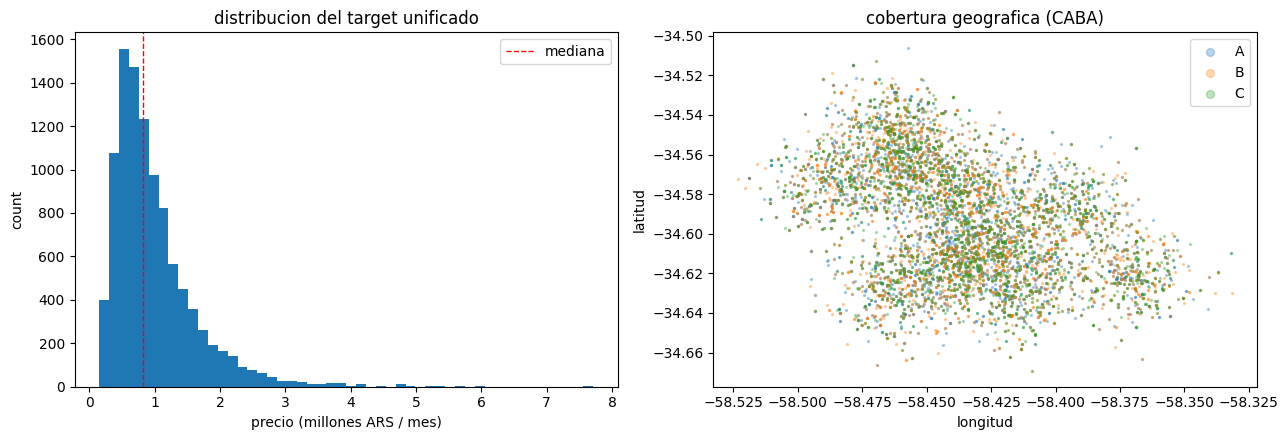

In [25]:
# distribucion del target unificado y mapa de los listings (lat/lng) por plataforma
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(df['precio_ars_mes'] / 1e6, bins=50)
axes[0].axvline(df['precio_ars_mes'].median() / 1e6, color='red', lw=1, ls='--', label='mediana')
axes[0].set_xlabel('precio (millones ARS / mes)')
axes[0].set_ylabel('count')
axes[0].set_title('distribucion del target unificado')
axes[0].legend()

for plat, color in [('A', 'tab:blue'), ('B', 'tab:orange'), ('C', 'tab:green')]:
    sub = df[df['plataforma'] == plat]
    axes[1].scatter(sub['lng'], sub['lat'], s=2, alpha=0.3, label=plat, color=color)
axes[1].set_xlabel('longitud')
axes[1].set_ylabel('latitud')
axes[1].set_title('cobertura geografica (CABA)')
axes[1].legend(markerscale=4)

plt.tight_layout()
plt.show()

In [26]:
# guardo a parquet
out_path = OUT / 'dataset_unificado.parquet'
df.to_parquet(out_path, index=False)
print(f'guardado: {out_path} ({out_path.stat().st_size / 1024:.0f} KB)')

guardado: ..\output\dataset_unificado.parquet (332 KB)


## resumen

A va con latin1, sino se rompen los ñ y aparecen barrios que no existen.

El precio de A viene mezclado: la mayoría sin signo, algunas con `$` y rangos absurdos (typos masivos), y un 9.5% en USD. Los USD los paso a pesos a 1100, que es lo que dan los mismos datos: mediana USD 735 × 1100 = 810k, casi exacto la mediana general en pesos. Después filtro lo que cae fuera de 100k–10M para sacar los typos sin tirar la cola alta legítima.

C trae 8% de precios como "Consultar". Como sin target no entreno, esas filas se van al final. El resto de las features de C salen con regex sobre la descripción.

Expensas solo está en A y tiene cola gordísima (p99 = 12M, max = 45M). En vez de descartar, clipeo al p99 — la cola es real. Y como falta en casi la mitad, le dejo un flag de missing.

Lo mismo con antigüedad y m2_total: nulos sistémicos. Esos los imputo cuando modele, acá solo flag por columna.

Para el unificado: prefijo de plataforma en el id, tipos a `depto/ph/casa`, barrios en minúscula. Categóricos donde corresponde y Int64 nullable para los conteos.